In [ ]:
# Author : Ray(Xurui Wang)

In [ ]:
# IMPORT SECTION
# We have to start an import section in order to make it easier to MAINTAIN
import datetime # for me the dates and time
import pandas as pd # for DATA FRAMES aka the n.n data
import matplotlib.pyplot as plt #for the plots
import pandas_datareader.data as web # in industry we use GCP (Ggle Cloud Plt)
import numpy as np
import seaborn as sns
from scipy.stats.mstats import winsorize
import yfinance as yf # YAHOO finance gives free api calls to the  values of the stock markets

In [ ]:
stock_ticker = "GFTC" # String : to reprents labels or name s
market_price = 150.25 # Float
share_traded = 1000 #Integer
is_volatile = True # Boolean
print(f"Asset: {stock_ticker}")
print(f"Market Prices:{market_price}")
print(f"Shares Traded: {share_traded}")
print(f"Is Volatile:{is_volatile}")
print(f"Asset: {stock_ticker} | Market Price: {market_price} | Shares Traded: {share_traded}")

Asset: GFTC
Market Prices:150.25
Shares Traded: 1000
Is Volatile:True
Asset: GFTC | Market Price: 150.25 | Shares Traded: 1000


In [ ]:
# Create a dictionary in Finance hardcoded values
data = {
    'stock_ticker': stock_ticker,
    'market_price': market_price,
    'share_traded': share_traded,
    'is_volatile': is_volatile
}
print(data)

{'stock_ticker': 'GFTC', 'market_price': 150.25, 'share_traded': 1000, 'is_volatile': True}


In [ ]:
ata = https://github.com/Sitraka17/Sitraka17/blob/main/README.md


SyntaxError: invalid syntax (1723479397.py, line 1)

In [ ]:
data = { 'Asset_ID': ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10'], 'Sector': ['Tech', 'Fin', 'Tech', 'Energy', 'Fin', 'Tech', 'Energy', 'Tech', 'Retail', 'Retail'], 'Returns': [0.05, 0.02, -0.01, 0.08, np.nan, 0.04, 0.15, -0.02, 0.01, 5.0], 'Volatility': [0.12, 0.08, 0.15, 0.20, 0.10, 0.11, 0.25, 0.13, 0.09, 0.10], 'Description': ['High growth tech', 'Stable financial', 'Volatile software', 'Oil production', 'Unknown bank', 'AI startup', 'Solar energy', 'E-commerce', 'Store A', 'Store B'] }

In [ ]:
df_fin = pd.DataFrame(data)
display(df_fin.head(10))


,Asset_ID,Sector,Returns,Volatility,Description
0,A1,Tech,0.05,0.12,High growth tech
1,A2,Fin,0.02,0.08,Stable financial
2,A3,Tech,-0.01,0.15,Volatile software
3,A4,Energy,0.08,0.20,Oil production
4,A5,Fin,NaN,0.10,Unknown bank
5,A6,Tech,0.04,0.11,AI startup
6,A7,Energy,0.15,0.25,Solar energy
7,A8,Tech,-0.02,0.13,E-commerce
8,A9,Retail,0.01,0.09,Store A
9,A10,Retail,5.00,0.10,Store B


In [ ]:
# Missing Values
# What do you do when you have missing values?
# The risk of missing values is to have BIAS RESULTS
# MAR/MCAR/MNAR(Missing at random/ missing completely at random/
# missing not at random(related to the value itself))



In [ ]:
df_fin['Returns_Imp'] = df_fin['Returns'].fillna(df_fin['Returns'].mean())
display(df_fin.head(10))

,Asset_ID,Sector,Returns,Volatility,Description,Returns_Imp,Returns_Clean
0,A1,Tech,0.05,0.12,High growth tech,0.050000,-0.02
1,A2,Fin,0.02,0.08,Stable financial,0.020000,-0.02
2,A3,Tech,-0.01,0.15,Volatile software,-0.010000,-0.02
3,A4,Energy,0.08,0.20,Oil production,0.080000,-0.02
4,A5,Fin,NaN,0.10,Unknown bank,0.591111,-0.02
5,A6,Tech,0.04,0.11,AI startup,0.040000,-0.02
6,A7,Energy,0.15,0.25,Solar energy,0.150000,-0.02
7,A8,Tech,-0.02,0.13,E-commerce,-0.020000,-0.02
8,A9,Retail,0.01,0.09,Store A,0.010000,-0.02
9,A10,Retail,5.00,0.10,Store B,5.000000,-0.02


In [ ]:
print(f"Gaps filed with the means is not perfect but good. Total NaNs now:{df_fin['Returns_Imp'].isna().sum()}")

Gaps filed with the means is not perfect but good. Total NaNs now:0


In [ ]:
# 4.Outliers & Winsorisation
# In finance we tend to often see 'FAT TAILS', Single error can RUIN a model.
# Winsorisation CAPS extreme values at specific percentiles rather than deleting them.
df_fin['Returns_Clean'] = winsorize(df_fin['Returns'], limits = [0.05,0.95])
display(df_fin.head(10))

,Asset_ID,Sector,Returns,Volatility,Description,Returns_Imp,Returns_Clean
0,A1,Tech,0.05,0.12,High growth tech,0.050000,-0.02
1,A2,Fin,0.02,0.08,Stable financial,0.020000,-0.02
2,A3,Tech,-0.01,0.15,Volatile software,-0.010000,-0.02
3,A4,Energy,0.08,0.20,Oil production,0.080000,-0.02
4,A5,Fin,NaN,0.10,Unknown bank,0.591111,-0.02
5,A6,Tech,0.04,0.11,AI startup,0.040000,-0.02
6,A7,Energy,0.15,0.25,Solar energy,0.150000,-0.02
7,A8,Tech,-0.02,0.13,E-commerce,-0.020000,-0.02
8,A9,Retail,0.01,0.09,Store A,0.010000,-0.02
9,A10,Retail,5.00,0.10,Store B,5.000000,-0.02


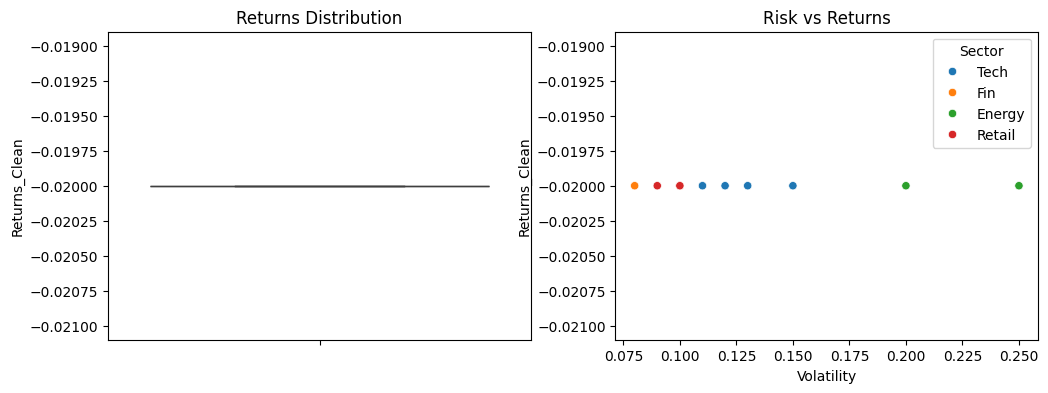

In [ ]:
from pandas.plotting import boxplot
# DATA VIZ(visualization)
plt.figure(figsize = (12,4))
plt.subplot(1,2,1)
sns.boxplot(df_fin['Returns_Clean']).set_title("Returns Distribution")
plt.subplot(1,2,2)
sns.scatterplot(data = df_fin, x = "Volatility", y ='Returns_Clean',hue = 'Sector').set_title("Risk vs Returns")
plt.show()


In [ ]:
# The cool Econometrics paart
# What is the PACKAGE used for STATISTICAL MODEL ???
import statsmodels.api as sm


In [ ]:
X = sm.add_constant(df_fin['Volatility'])
y = df_fin['Returns_Clean']
model = sm.OLS(y,X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:          Returns_Clean   R-squared:                     -12.900
Model:                            OLS   Adj. R-squared:                -14.638
Method:                 Least Squares   F-statistic:                    -7.424
Date:                Mon, 15 Jun 2026   Prob (F-statistic):               1.00
Time:                        13:12:10   Log-Likelihood:                 374.68
No. Observations:                  10   AIC:                            -745.4
Df Residuals:                       8   BIC:                            -744.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0200   1.28e-17  -1.57e+15      0.0

In [ ]:
# Import a sub part of sklearn
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3,n_init=10,random_state=42).fit(df_fin[['Volatility','Returns_Clean']])
df_fin['Risk_Group'] = kmeans.labels_
print("Assets assigned to risk clusters.")


Assets assigned to risk clusters.


In [ ]:
# But we need more! We need to Predict
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import classification_report # to ease the human reading

df_fin["Target"] = (df_fin['Sector']== 'Tech').astype(int)
x_clf = df_fin[['Volatility','Returns_Clean']]
y_clf = df_fin['Target']
clf = DecisionTreeRegressor().fit(x_clf,y_clf)
df_fin['Prediction'] = clf.predict(x_clf)

print (classification_report(y_clf,df_fin['Prediction']))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         4

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



In [ ]:
# write a call to get sp500 data with web.DataReader

In [ ]:
# write a call to get sp500 data with web.DataReader
sp500_ticker = '^GSPC'  # Ticker symbol for S&P 500
start_date = datetime.datetime(2020, 1, 1)
end_date = datetime.datetime(2023, 12, 31)

sp500_data = yf.download(sp500_ticker, start=start_date, end=end_date)
display(sp500_data.head())

/tmp/ipykernel_4275/980550051.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  sp500_data = yf.download(sp500_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2020-01-02,3257.850098,3258.139893,3235.530029,3244.669922,3459930000
2020-01-03,3234.850098,3246.149902,3222.340088,3226.360107,3484700000
2020-01-06,3246.280029,3246.840088,3214.639893,3217.550049,3702460000
2020-01-07,3237.179932,3244.909912,3232.429932,3241.860107,3435910000
2020-01-08,3253.050049,3267.070068,3236.669922,3238.590088,3726840000


1. Using SQLite (in-Memory)

We can use the built-in sqlite3 module to create a temproary database from our existing DataFrame.


In [ ]:
# Since it is more than just 'simple Data Analytics
# We will need to INSTALL the SQL package
!pip install pandasql
# To install it you need the EXCLMATION point and the pip

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=bdde8d9697b971fb6fd567bd50ff97163db9d49e7383e4577741534be24d23a3
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


In [ ]:
import sqlite3
# do-bite-json-SQL-df-excel-structure

In [ ]:
conn = sqlite3.connect(':memory:')
# this creates an in-memory SQLite DB (database) so u use the vm of google

In [ ]:
df_fin.to_sql('finance_table',conn, index = False, if_exists = 'replace')# write the existing Pa to SQL database
# what are three words used in SQL (Select, from, where)(or group by here)
#FTX: we must ensure the table is created

query = "SELECT Sector, AVG(Volatility) as Avg_Vol FROM finance_table GROUP BY Sector"
sql_results = pd.read_sql(query,conn)
print(sql_results)
#

   Sector  Avg_Vol
0  Energy   0.2250
1     Fin   0.0900
2  Retail   0.0950
3    Tech   0.1275


In [ ]:
#what if I want only SQL and no more pandas?
#Use a LAMBDA function
from pandasql import sqldf
pysqldf = lambda q: sqldf(q, globals())
query_ps = """
SELECT Asset_ID, Sector, Returns_Clean
FROM df_fin
WHERE Sector = 'Tech'
"""

print (pysqldf(query_ps))

  Asset_ID Sector  Returns_Clean
0       A1   Tech          -0.02
1       A3   Tech          -0.02
2       A6   Tech          -0.02
3       A8   Tech          -0.02


In [ ]:
# Get data: https://github.com/Sitraka17/Sitraka17/blob/main/README.md

asset_metadata = pd.DataFrame({
    'Asset_ID': ['A1', 'A2', 'A3', 'A4', 'A5'],
    'Full_Name': ['Apple Inc', 'JP Morgan', 'Microsoft', 'Exxon Mobil',
    'Goldman Sachs'], 'Country': ['USA', 'USA', 'USA', 'USA', 'USA']
    })

In [ ]:
# The advantage of SQL is the Power of JOINNING Tables
# The most used one is Inner join
# We will do an api call for the FRED
fred_df_sql = sql= fred_data.reset_index()

NameError: name 'fred_data' is not defined

In [ ]:
query_fred = """
SELECT DATE, GDP
ORDER BY DATE DESC
"""
gdp_high_results = pysqldf(query_fred)
print(gdp_high_results)
#